![ai](https://www.emineo-education.fr/wp-content/uploads/2022/11/supdevinci-nantes.png)


<h4 style="text-align: left; color:#20a08d; font-size: 35px"><span><strong> Assurez la modération des contenus multimédia avec AWS</strong></span></h4>

<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Introduction
</strong></span></h4>

Le saviez-vous ? Les réseaux sociaux du groupe Meta Facebook et Instagram recueillent environ 2 milliards d'images de leurs utilisateurs tous les jours. Imaginez toute l'infrastructure informatique nécessaire pour traiter toutes ces données

![](https://github.com/archiducarmel/SupDeVinci_Developpement/releases/download/ia_ml_aws/fb.gif)

Afin de fournir des services intuitifs à leurs utilisateurs, plusieurs traitements sont réalisés sur chacune de ces images.

![](https://github.com/archiducarmel/SupDeVinci_Developpement/releases/download/ia_ml_aws/fb2.png)

Nous allons utiliser dans ce TP les services AWS pour réaliser quelques-uns de ces fonctionnalités. La finalité ultime consiste à développer une fonction de traitement qui recueille une image ou une vidéo en entrée, la modère afin de vérifier si son contenu est publiable, produit des sous-titres (dans le cas des vidéos) et fournit des hashtags issus de mots les plus représentatifs du contenu.

<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Workflow de traitement
</strong></span></h4>

Voici ci-dessous le procédé de traitement qui sera appliqué de bout-en-bout sur toute image présentée en entrée de la fonction de traitement.

![](https://github.com/archiducarmel/SupDeVinci_Developpement/releases/download/ia_ml_aws/aws_socialmedia.drawio.png)

<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Détection du type de fichier
</strong></span></h4>

La fonction `check_filetype` ci-dessous permet de déterminer le type (image ou vidéo) d'un fichier fourni en entrée.

In [2]:
import os

import os

def check_filetype(filename):
    """
    Détermine le type de fichier en fonction de son extension.

    Cette fonction prend un nom de fichier en entrée, extrait son extension et détermine
    le type de fichier (par exemple, image, vidéo). Si l'extension du fichier est reconnue comme un format
    d'image courant (jpg, png, tiff, svg) ou un format de vidéo courant (mp4, avi, mkv), elle attribue
    le type correspondant. Sinon, le type de fichier est défini sur None.

    Paramètres :
    - filename (str) : Le chemin vers le fichier incluant le nom de fichier.

    Retourne :
    - str ou None : Le type de fichier déterminé ('image', 'vidéo') ou None si le type de fichier
      n'est pas reconnu.

    Exemple :
    >>> check_filetype("/chemin/vers/image.jpg")
    'image'
    >>> check_filetype("/chemin/vers/video.mp4")
    'vidéo'
    >>> check_filetype("/chemin/vers/fichierinconnu.xyz")
    None
    """

    # Extrait le nom de base du fichier à partir du chemin de fichier fourni.
    file_basename = os.path.basename(filename)

    # Sépare le nom de base sur le point et prend la dernière partie comme extension.
    extension = file_basename.split(".")[-1]

    # Détermine le type de fichier en fonction de l'extension.
    if extension in ["jpg", "png", "tiff", "svg"]:
        filetype = "image"
    elif extension in ["mp4", "avi", "mkv"]:
        filetype = "vidéo"
    else:
        filetype = None

    # Enregistre le type de fichier détecté.
    print(f"[INFO] : Le fichier {file_basename} est de type : {filetype}")
    
    return filetype


<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">check_filetype</code> sur la vidéo de test et l'image de test afin d'en détecter le type</span></p>

In [ ]:
TEST_VIDEO_FILE = "./assets/tuto_maquillage.mp4"
TEST_IMAGE_FILE = "./assets/selfie_with_johnny-depp.png"

# Vérification du type de fichier pour la vidéo
video_type = check_filetype(TEST_VIDEO_FILE)
print(f"Type du fichier vidéo : {video_type}")

# Vérification du type de fichier pour l'image
image_type = check_filetype(TEST_IMAGE_FILE)
print(f"Type du fichier image : {image_type}")


[INFO] : Le fichier tuto_maquillage.mp4 est de type : vidéo
Type du fichier vidéo : vidéo
[INFO] : Le fichier selfie_with_johnny-depp.png est de type : image
Type du fichier image : image


<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Extraction d'une image de la vidéo
</strong></span></h4>

La fonction `extract_frame_video` ci-dessous permet d'extraire une image sous forme de tableau de pixels d'une vidéo à partir de la position de l'image dans la vidéo

In [23]:
import cv2

def extract_frame_video(video_path, frame_id):
    """
    Extrait une image spécifique d'une vidéo.

    Cette fonction utilise OpenCV pour ouvrir une vidéo à partir du chemin spécifié et extrait une image
    particulière en fonction de son ID. L'ID de l'image correspond à l'ordre de l'image dans la vidéo, en commençant
    par 0 pour la première image. Si l'extraction réussit, l'image est retournée sous forme d'un tableau Numpy.

    Paramètres :
    - video_path (str) : Le chemin vers le fichier vidéo d'où extraire l'image.
    - frame_id (int) : L'identifiant (ID) de l'image à extraire.

    Retourne :
    - ndarray ou None : L'image extraite (un tableau Numpy) si l'extraction est réussie,
      sinon `None`.

    Exemple :
    >>> image = extract_frame_video("/chemin/vers/video.mp4", 150)
    >>> type(image)
    <class 'numpy.ndarray'>
    """

    # Ouvre la vidéo à partir du chemin fourni.
    video = cv2.VideoCapture(video_path)

    # Positionne le lecteur vidéo sur l'image spécifiée par frame_id.
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

    # Lit l'image actuelle.
    ret, image = video.read()

    # Si la lecture réussit (ret est True), retourne l'image.
    # Sinon, retourne None.
    return image if ret else None

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">extract_frame_video</code> sur la vidéo de test afin d'en extraire la première image de la vidéo, puis affichez cette image avec <code style="text-align: left; font-size: 16px; color:#131fcf">matplotlib</code></span></p>

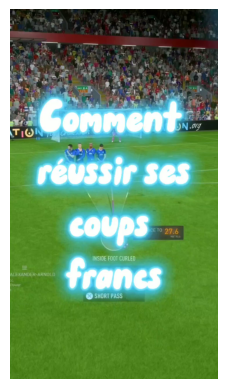

In [ ]:
%matplotlib inline
from matplotlib import pyplot as plt
import cv2

TEST_VIDEO_FILE = "./assets/tuto_jeux-video.mp4"

# Extraction de la première image (frame 0)
first_frame = extract_frame_video(TEST_VIDEO_FILE, 0)

# Vérifier si l'image a bien été extraite
if first_frame is not None:
    # OpenCV charge l'image en BGR, on la convertit en RGB pour un bon affichage avec Matplotlib
    first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

    # Affichage avec Matplotlib
    plt.imshow(first_frame)
    plt.axis("off")
    plt.show()
else:
    print("Erreur : Impossible d'extraire l'image.")


<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">extract_frame_video</code> sur la vidéo de test afin d'en extraire la quatre vingt dix-neuvième image de la vidéo, puis affichez cette image avec <code style="text-align: left; font-size: 16px; color:#131fcf">matplotlib</code></span></p>

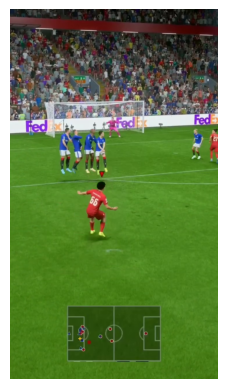

In [54]:
import matplotlib.pyplot as plt
import cv2

image = extract_frame_video("./assets/tuto_jeux-video.mp4", 98)

if image is not None:

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Erreur : Impossible d'extraire l'image.")


<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Modération d'une image
</strong></span></h4>

La fonction `get_aws_session` ci-dessous permet de se connecter à une session AWS en utilisant les clés d'accès et clés secrètes.

In [9]:
!pip install boto3 python-dotenv 
!pip install nltk


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 11.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import os, boto3
from dotenv import load_dotenv

def get_aws_session():
    """
    Crée et retourne une session AWS.

    Cette fonction charge les variables d'environnement depuis un fichier .env situé dans le répertoire
    courant ou les parents de celui-ci, récupère les clés d'accès AWS (`ACCESS_KEY` et `SECRET_KEY`),
    et initialise une session AWS avec ces identifiants ainsi qu'avec une région spécifiée (dans cet exemple,
    'us-east-1'). Elle est particulièrement utile pour configurer une session AWS de manière sécurisée sans
    hardcoder les clés d'accès dans le code.

    Retourne :
    - Session : Un objet session de boto3 configuré avec les clés d'accès et la région AWS.

    Exemple d'utilisation :
    >>> session_aws = get_aws_session()
    >>> type(session_aws)
    <class 'boto3.session.Session'>
    """

    # Charge les variables d'environnement depuis .env.
    load_dotenv()

    # Crée une session AWS avec les clés d'accès et la région définies dans les variables d'environnement.
    aws_session = boto3.Session(
        aws_access_key_id=os.getenv("ACCESS_KEY"),
        aws_secret_access_key=os.getenv("SECRET_KEY"),
        region_name="euw-west-2"
    )
    
    # Retourne l'objet session créé.
    return aws_session


Passons maintenant au développement de la fonction `moderate_image`. Cette fonction prendra en entrée une image et renverra la liste des thèmes choquants présents dans l'image, s'il y'en a. 

<p style="text-align: left; font-size: 16px; color:#7a0f43"><span>❓ Quelle service AWS serait le plus indiqué pour réaliser ce traitement ?</span></p>

In [ ]:
# Réponse :
# Amazon Rekognition car il permet de détecter des objets,
# des visages et des scènes.
# Ainsi que du contenu innaproprié
# puis faire de la reconnaissance faciale."

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code dans la fonction  <strong>moderate_image</strong> permettant d'analyser une image et détecter les sujets de modération </span></p>

In [26]:
import boto3

def moderate_image(image_path, aws_service):
    """
    Détecte du contenu nécessitant une modération dans une image en utilisant un service AWS spécifié.

    Cette fonction ouvre une image depuis un chemin donné, puis utilise le service AWS (comme Amazon Rekognition)
    pour détecter les contenus potentiellement inappropriés ou sensibles (comme la nudité, la violence, etc.).
    Elle collecte et retourne une liste des étiquettes de modération identifiées pour cette image.

    Paramètres :
    - image_path (str) : Le chemin vers l'image à analyser.
    - aws_service (object) : Un objet de service AWS configuré, capable de réaliser des opérations de détection
      de contenu nécessitant une modération (par exemple, un client Amazon Rekognition).

    Retourne :
    - list[str] : Une liste des noms des étiquettes de modération détectées pour l'image.

    Exemple d'utilisation :
    >>> aws_rekognition_client = boto3.client('rekognition', region_name='us-east-1')
    >>> moderate_image("/chemin/vers/image.jpg", aws_rekognition_client)
    ['Nudity', 'Explicit Violence']
    """

    # Ouvrir l'image en mode binaire
    with open(image_path, "rb") as image_file:
        image_bytes = image_file.read()

    # Appel à l'API Rekognition pour détecter les contenus sensibles
    response = aws_service.detect_moderation_labels(
        Image={'Bytes': image_bytes}
    )

    # Extraire les étiquettes détectées
    labels = [label['Name'] for label in response['ModerationLabels']]

    return labels


<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code permettant de tester la fonction  <strong>moderate_image</strong>. Pour ce faire : <ul style="text-align: left; font-size: 16px; color:#131fcf">
    <li>Instancier une session AWS avec vos clés</li>
    <li>Instancier le service AWS approprié pour ce traitement </li>
    <li>Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">moderate_image</code> avec ce service comme argument afin de recueillir la liste potentielle des thèmes choquants</li>
    </ul> </span></p>

In [56]:
aws_session = boto3.Session(
    aws_access_key_id=os.getenv("ACCESS_KEY"),
    aws_secret_access_key=os.getenv("SECRET_KEY"),
    region_name="euw-west-2"
)


In [57]:
# Instancier le client Rekognition
rekognition_client = session.client('rekognition')

# Chemins vers les images de test
TEST_IMAGE_FILE_1 = "./assets/haine.png"
TEST_IMAGE_FILE_2 = "./assets/vulgaire.png"
TEST_IMAGE_FILE_3 = "./assets/violence1.png"
TEST_IMAGE_FILE_4 = "./assets/no-violence1.png"

# Tester la fonction `moderate_image` sur plusieurs images
def test_moderation():
    image_files = [TEST_IMAGE_FILE_1, TEST_IMAGE_FILE_2, TEST_IMAGE_FILE_3, TEST_IMAGE_FILE_4]
    
    for image_file in image_files:
        print(f"Analyse de l'image : {image_file}")
        try:
            # Appel de la fonction de modération avec le service Rekognition
            labels = moderate_image(image_file, rekognition_client)
            
            # Affichage des résultats
            if labels:
                print(f"Étiquettes de modération détectées dans {image_file}: {labels}")
            else:
                print(f"Aucune étiquette de modération détectée dans {image_file}.")
        except Exception as e:
            print(f"Erreur lors de l'analyse de l'image {image_file}: {e}")
        print("-" * 50)

# Exécution du test
test_moderation()

Analyse de l'image : ./assets/haine.png
Erreur lors de l'analyse de l'image ./assets/haine.png: name 'moderate_image' is not defined
--------------------------------------------------
Analyse de l'image : ./assets/vulgaire.png
Erreur lors de l'analyse de l'image ./assets/vulgaire.png: name 'moderate_image' is not defined
--------------------------------------------------
Analyse de l'image : ./assets/violence1.png
Erreur lors de l'analyse de l'image ./assets/violence1.png: name 'moderate_image' is not defined
--------------------------------------------------
Analyse de l'image : ./assets/no-violence1.png
Erreur lors de l'analyse de l'image ./assets/no-violence1.png: name 'moderate_image' is not defined
--------------------------------------------------


<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Production de sous-titres
</strong></span></h4>

La production de sous-titres à partir d'une vidéo s'appuiera sur la technologie speech-to-text d'AWS.

<div class="alert alert-info">
  <strong>BUCKET S3</strong><br><br> Au préalable, assurez-vous d'avoir créé un bucket S3 puisque la transcription speech-to-text nécessite que le fichier transcrit soit déposé dans un bucket S3
</div>

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code permettant d'instancier un client S3 puis de créer un bucket </span></p>

In [58]:
import boto3
import time
from botocore.exceptions import ClientError

aws_session = boto3.Session(
    aws_access_key_id=os.getenv("ACCESS_KEY"),
    aws_secret_access_key=os.getenv("SECRET_KEY"),
    region_name="euw-west-2"
)

s3_client = session.client('s3')

bucket_name = "tp-jour2"

try:
    s3_client.create_bucket(
        Bucket=bucket_name,
        CreateBucketConfiguration={
            'LocationConstraint': 'eu-west-2'
        }
    )
    print(f"Le bucket '{bucket_name}' a été créé avec succès.")
except ClientError as e:
    if e.response['Error']['Code'] == 'OperationAborted':
        print("Une opération conflictuelle est en cours, réessayer dans 5 secondes...")
        time.sleep(5)
        try:
            s3_client.create_bucket(
                Bucket=bucket_name,
                CreateBucketConfiguration={
                    'LocationConstraint': 'eu-west-2'
                }
            )
            print(f"Le bucket '{bucket_name}' a été créé avec succès après la réessayer.")
        except Exception as e:
            print(f"Erreur lors de la création du bucket après réessayer : {e}")
    else:
        print(f"Erreur lors de la création du bucket : {e}")


Erreur lors de la création du bucket : An error occurred (BucketAlreadyOwnedByYou) when calling the CreateBucket operation: Your previous request to create the named bucket succeeded and you already own it.


<p style="text-align: left; font-size: 16px; color:#7a0f43"><span>❓ Quelle service AWS serait le plus indiqué pour réaliser ce traitement de transcription speech-to-text ?</span></p>

In [ ]:
# Réponse :
# Amazon Transcribe car il convertit automatiquement 
# l'audio en texte avec précision.

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code de la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">get_text_from_speech</code> permettant de réaliser la transcription speech-to-text avec AWS</span></p>

<p style="text-align: left; font-size: 16px; color:#ec8f1a"><span>📚  Voice to text using AWS Transcribe : </span> <a href="https://dev.to/botreetechnologies/voice-to-text-using-aws-transcribe-with-python-1cfc">https://dev.to/botreetechnologies/voice-to-text-using-aws-transcribe-with-python-1cfc</a></p> 

In [59]:
import os
import time
import urllib.request
import json

def get_text_from_speech(filename, aws_service, job_name, bucket_name):
    """
    Convertit de la parole en texte en utilisant AWS Transcribe.

    Cette fonction téléverse un fichier audio spécifié dans un seau S3, démarre un travail de transcription avec AWS Transcribe,
    attend que le travail soit terminé, et récupère le texte transcrit.

    Paramètres :
    - filename (str) : Chemin local vers le fichier audio à transcrire.
    - aws_service (object) : Client AWS Transcribe configuré.
    - job_name (str) : Nom unique pour le travail de transcription.
    - bucket_name (str) : Nom du seau S3 où le fichier audio est stocké.

    Retourne :
    - str : Le texte transcrit du fichier audio.

    Prérequis :
    - Le fichier audio doit déjà être téléversé dans le seau S3 spécifié.
    """
    img = filename.split("/")[-1]

    s3_uri = f"s3://{bucket_name}/{img}"

    # Démarrer la transcription avec la bonne URL S3
    aws_service.start_transcription_job(
        TranscriptionJobName=job_name,
        Media={'MediaFileUri': s3_uri},
        MediaFormat='mp4',  # Assurez-vous que c'est bien le format du fichier !
        LanguageCode='fr-FR'
    )

    # Attendre que le job soit terminé
    while True:
        status = aws_service.get_transcription_job(TranscriptionJobName=job_name)
        job_status = status["TranscriptionJob"]["TranscriptionJobStatus"]

        if job_status in ["COMPLETED", "FAILED"]:
            break
        print(f"Job en cours... ({job_status})")
        time.sleep(10)

    if job_status == "COMPLETED":
        # Récupérer l'URL du fichier transcrit
        transcript_url = status["TranscriptionJob"]["Transcript"]["TranscriptFileUri"]

        # Télécharger le JSON contenant le texte transcrit
        with urllib.request.urlopen(transcript_url) as response:
            data = json.loads(response.read())

        return data["results"]["transcripts"][0]["transcript"]
    else:
        return "La transcription a échoué."

    return f"Transcription job '{job_name}' started for {s3_uri}"

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code permettant de tester la fonction  <strong>get_text_from_speech</strong>. Pour ce faire : <ul style="text-align: left; font-size: 16px; color:#131fcf">
    <li>Uploader la vidéo de test sur le bucket de test préalablement créé</li>
    <li>Instancier le service AWS approprié pour ce traitement </li>
    <li>Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">get_text_from_speech</code> avec ce service comme argument afin de recueillir le texte recueilli</li>
    </ul> </span></p>

In [61]:
import boto3

# Créez une session boto3
aws_session = boto3.Session(
    aws_access_key_id=os.getenv("ACCESS_KEY"),
    aws_secret_access_key=os.getenv("SECRET_KEY"),
    region_name="euw-west-2"
)

# Créez le client S3
s3 = session.client('s3')

# Spécifiez le nom du seau et du fichier vidéo de test
TEST_VIDEO_FILE = "./assets/tuto_coiffure.mp4"
BUCKET_NAME = 'tp-jour2'

# Téléchargez le fichier vidéo dans le seau S3
img = TEST_VIDEO_FILE.split("/")[-1]
s3.upload_file(TEST_VIDEO_FILE, BUCKET_NAME, img)

# Créez un client pour le service AWS Transcribe
transcribe = session.client('transcribe')

# Appelez la fonction pour obtenir le texte transcrit
sousTitre = get_text_from_speech(TEST_VIDEO_FILE, transcribe, "test8", BUCKET_NAME)

# Affichez le texte transcrit
print(sousTitre)


Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
je me fais une petite coiffure qui est scooter parce que dans Paris en ce moment, c'est du grand n'importe quoi, que ce soit au niveau des transports en commun, au niveau des taxis. Bref, c'est le gros bordel. Donc on s'est dit Ouais, le scooter, ça peut être plus facile pour les rendez-vous. Du coup, on prend les scooters, vous savez électriques en location là qui sont partout dans la rue. Et le petit souci, c'est que du coup on prend les casques d'autrui, les gens passent et prennent leur casque. Logique. Et même s'il y a des Charlotte, j'avoue que moi ça me j'ai un peu de mal. Donc aujourd'hui on va acheter nos propres casques. Ah, j'ai fait des petites parties comme ça et maintenant je vais faire une deuxième section derrière. Je vais bien tout tuer. Voilà à quoi ça ressemble

<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Production de hashtags d'une séquence vidéo
</strong></span></h4>

La production de hashtag sur une séquence vidéo se base sur le texte extrait de la vidéo après l'étape de speech-to-text, qui sera utilisé pour en extraire des mots-clés (keyphrases). Au préalable, le texte extrait devra être nettoyé pour y enlever quelques éléments inutiles. C'est la fonction de la fonction `clean_text`

In [62]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer

def clean_text(raw_text):
    """
    Nettoie un texte en retirant les mots vides et en normalisant les mots en minuscules.

    Paramètres :
    - raw_text (str) : Le texte brut à nettoyer.

    Retourne :
    - str : Le texte nettoyé, sans mots vides et en minuscules.
    """
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(raw_text.lower())
    
    stop_words = set(stopwords.words('french'))
    
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    cleaned_text = ' '.join(filtered_tokens)
    
    return cleaned_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\louca\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">clean_text</code> le texte extrait afin de recueillir un texte nettoyé</span></p>

In [63]:
extracted_text = "Ceci est un exemple de texte à nettoyer. Il contient des mots vides et d'autres éléments."
cleaned_text = clean_text(extracted_text)

print("Texte nettoyé :")
print(cleaned_text)


Texte nettoyé :
ceci exemple texte nettoyer contient mots vides autres éléments


<p style="text-align: left; font-size: 16px; color:#7a0f43"><span>❓ Quelle service AWS serait le plus indiqué pour réaliser ce traitement d'extraction des "key phrases" ?</span></p>

In [ ]:
#Réponse :
# Amazon Comprehend

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code de la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">extract_keyphrases</code> permettant d'extraire les mots clés d'un texte en entrée. Ne retenez que les 10 mots-clés détectés avec le plus de confiance</span></p>

In [64]:
import boto3

def extract_keyphrases(text, aws_service):
    """
    Extrait les expressions clés d'un texte et retourne les 10 expressions les plus pertinentes comme hashtags.

    Cette fonction utilise un service AWS, tel que Amazon Comprehend, pour détecter les expressions clés dans
    un texte donné. Elle trie ces expressions par leur score de pertinence fourni par AWS et retourne les 10
    expressions clés les plus pertinentes sous forme de hashtags.

    Paramètres :
    - text (str) : Le texte duquel extraire les expressions clés.
    - aws_service (object) : Un objet de service AWS configuré pour détecter les expressions clés.

    Retourne :
    - list[str] : Une liste des 10 hashtags les plus pertinents basés sur les expressions clés du texte.
    """
    response = aws_service.detect_key_phrases(
        Text=text,
        LanguageCode='fr'
    )

    key_phrases = response['KeyPhrases']

    top_key_phrases = sorted(key_phrases, key=lambda x: x['Score'], reverse=True)[:10]

    hashtags = ['#' + phrase['Text'].replace(' ', '').lower() for phrase in top_key_phrases]
    
    return hashtags

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code permettant de tester la fonction  <strong>extract_keyphrases</strong>. Pour ce faire : <ul style="text-align: left; font-size: 16px; color:#131fcf">
    <li>Instancier le service AWS approprié pour ce traitement </li>
    <li>Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">extract_keyphrases</code> avec ce service comme argument afin de recueillir la liste des mots-clés</li>
    </ul> </span></p>

In [65]:
import boto3

aws_session = boto3.Session(
    aws_access_key_id=os.getenv("ACCESS_KEY"),
    aws_secret_access_key=os.getenv("SECRET_KEY"),
    region_name="euw-west-2"
)

aws_comprehend_client = session.client('comprehend', region_name='us-east-1')

text_to_analyze = "Amazon Web Services (AWS) propose des solutions cloud pour les entreprises. AWS offre des services de calcul, de stockage et d'analytique."

key_phrases = extract_keyphrases(text_to_analyze, aws_comprehend_client)

print("Mots-clés extraits :", key_phrases)


Mots-clés extraits : ['#aws', '#desservicesdecalcul', '#amazonwebservices', '#aws', '#stockage', '#dessolutionscloud', '#lesentreprises', '#analytique']


<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Production de hashtags d'une image
</strong></span></h4>

La production de hashtags sur une image se base sur la détection des objets et des célébrités présents dans l'image.

<h4 style="text-align: left; color:#20a08d; font-size: 20px"><span><strong> Détection d'objets sur une image
</strong></span></h4>

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code de la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">detect_objects</code> permettant de détecter les objets présents sur une image donnée en entrée de la fonction. Ne retenez que les 10 objets détectés avec le plus de confiance.</span></p>

In [66]:
import boto3

def detect_objects(image_path, aws_service):
    """
    Détecte les objets dans une image en utilisant Amazon Rekognition.

    Cette fonction ouvre une image depuis un chemin spécifié, utilise un service AWS (Amazon Rekognition) pour
    détecter les objets présents dans l'image avec une confiance minimale de 50%, et retourne les noms des 10
    objets les plus pertinents détectés.

    Paramètres :
    - image_path (str) : Le chemin vers l'image à analyser.
    - aws_service (object) : Un client AWS Rekognition configuré.

    Retourne :
    - list[str] : Une liste contenant les noms des 10 premiers objets détectés dans l'image.
    """

    # Ouvrir l'image en mode binaire
    with open(image_path, "rb") as image_file:
        image_bytes = image_file.read()

    # Appeler l'API Rekognition pour détecter les objets dans l'image
    response = aws_service.detect_labels(
        Image={'Bytes': image_bytes},
        MinConfidence=50  # Seuls les objets avec une confiance > 50% seront retournés
    )

    # Trier les labels par leur confiance et garder les 10 premiers objets
    objects = sorted(response['Labels'], key=lambda x: x['Confidence'], reverse=True)[:10]

    # Extraire les noms des objets détectés
    object_names = [obj['Name'] for obj in objects]

    return object_names


<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code permettant de tester la fonction  <strong>detect_objects</strong>. Pour ce faire : <ul style="text-align: left; font-size: 16px; color:#131fcf">
    <li>Instancier le service AWS approprié pour ce traitement </li>
    <li>Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">detect_objects</code> avec ce service comme argument afin de recueillir la liste des objets présents sur cette image de test</li>
    </ul> </span></p>

In [67]:
import boto3

aws_session = boto3.Session(
    aws_access_key_id=os.getenv("ACCESS_KEY"),
    aws_secret_access_key=os.getenv("SECRET_KEY"),
    region_name="euw-west-2"
)

rekognition_client = session.client('rekognition', region_name='us-east-1')

TEST_IMAGE_FILE = "./assets/no-violence4.png"

detected_objects = detect_objects(TEST_IMAGE_FILE, rekognition_client)

print("Objets détectés dans l'image :", detected_objects)


Objets détectés dans l'image : ['People', 'Person', 'Walking', 'Boy', 'Child', 'Male', 'Female', 'Girl', 'Dancing', 'Leisure Activities']


<h4 style="text-align: left; color:#20a08d; font-size: 20px"><span><strong> Détection des célébrités sur une image
</strong></span></h4>

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code de la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">detect_celebrities</code> permettant de détecter les célébrités présents sur une image donnée en entrée de la fonction.</span></p>

In [68]:
import boto3

def detect_celebrities(image_path, aws_service):
    """
    Identifie les célébrités dans une image en utilisant le service Amazon Rekognition.

    Cette fonction ouvre une image depuis un chemin donné et utilise le service AWS Rekognition pour reconnaître les
    célébrités présentes dans l'image. Elle retourne une liste contenant les noms des célébrités identifiées, limitée
    aux 10 premiers résultats pour simplifier l'output.

    Paramètres :
    - image_path (str) : Le chemin vers l'image dans laquelle détecter les célébrités.
    - aws_service (object) : Un client AWS Rekognition configuré.

    Retourne :
    - list[str] : Une liste des noms des célébrités identifiées dans l'image, jusqu'à un maximum de 10.
    """

    # Ouvrir l'image en mode binaire
    with open(image_path, "rb") as image_file:
        image_bytes = image_file.read()

    # Appeler l'API Rekognition pour détecter les célébrités dans l'image
    response = aws_service.recognize_celebrities(
        Image={'Bytes': image_bytes}
    )

    # Extraire les noms des célébrités détectées
    celebrities = [celebrity['Name'] for celebrity in response.get('CelebrityFaces', [])]

    # Limiter les résultats à 10 célébrités
    return celebrities[:10]


<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code permettant de tester la fonction  <strong>detect_celebrities</strong>. Pour ce faire : <ul style="text-align: left; font-size: 16px; color:#131fcf">
    <li>Instancier le service AWS approprié pour ce traitement </li>
    <li>Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">detect_celebrities</code> avec ce service comme argument afin de recueillir la liste des célébrités présentes sur chacune des images de test</li>
    </ul> </span></p>

In [69]:
import boto3

aws_session = boto3.Session(
    aws_access_key_id=os.getenv("ACCESS_KEY"),
    aws_secret_access_key=os.getenv("SECRET_KEY"),
    region_name="euw-west-2"
)

rekognition_client = session.client('rekognition', region_name='us-east-1')

TEST_IMAGE_FILE_1 = "./assets/selfie_with_mariah-carey.png"
TEST_IMAGE_FILE_2 = "./assets/selfie_with_johnny-depp.png"
TEST_IMAGE_FILE_3 = "./assets/selfie_with_kanye-west.png"

test_images = [TEST_IMAGE_FILE_1, TEST_IMAGE_FILE_2, TEST_IMAGE_FILE_3]
for img in test_images:
    print(f"Détection de célébrités dans l'image {img}:")
    celebrities = detect_celebrities(img, rekognition_client)
    print("Célébrités détectées:", celebrities)
    print("-" * 40)


Détection de célébrités dans l'image ./assets/selfie_with_mariah-carey.png:
Célébrités détectées: ['Mariah Carey']
----------------------------------------
Détection de célébrités dans l'image ./assets/selfie_with_johnny-depp.png:
Célébrités détectées: ['Johnny Depp']
----------------------------------------
Détection de célébrités dans l'image ./assets/selfie_with_kanye-west.png:
Célébrités détectées: ['Kanye West', 'Maher Zain']
----------------------------------------


<h4 style="text-align: left; color:#20a08d; font-size: 20px"><span><strong> Reconnaissance d'émotion faciale sur une image
</strong></span></h4>

<span style="color:#131fcf">🖥️ Codez la fonction `detect_emotions` qui doit :

<ul style="color:#131fcf">
<li>Prendre en entrée :
  <ul>
    <li>Le chemin de l'image à analyser</li>
    <li>Le client AWS Rekognition configuré</li>
  </ul>
</li>

<li>Analyser l'image :
  <ul>
    <li>Ouvrir l'image en mode binaire</li>
    <li>Utiliser Rekognition avec <strong>detect_faces</strong></li>
    <li>Demander tous les attributs (Attributes=['ALL'])</li>
  </ul>
</li>

<li>Pour chaque visage détecté, afficher :
  <ul>
    <li>Le genre avec son niveau de confiance</li>
    <li>L'âge estimé (range min-max)</li>
    <li>Les 3 émotions principales avec leur niveau de confiance</li>
  </ul>
</li>

<li>Retourner la liste complète des informations des visages détectés</li>

<li>Exemple de sortie console attendue :
<code style="color:#131fcf">
[INFO] Visage détecté:
  - Genre: Male (confiance: 99.9%)
  - Âge estimé: 20-30 ans
  - Émotions principales:
    * HAPPY: 95.5%
    * CALM: 4.5%
---
</code>
</li>
</ul>
</span>

In [70]:
import boto3

def detect_emotions(image_path, aws_service):
    """
    Détecte les émotions sur les visages présents dans une image en utilisant Amazon Rekognition.
    
    Cette fonction analyse une image pour détecter les visages et leurs émotions associées.
    Pour chaque visage, elle retourne les émotions détectées avec leur niveau de confiance.
    
    Paramètres :
    - image_path (str) : Chemin vers l'image à analyser
    - aws_service (boto3.client) : Client AWS Rekognition configuré
    
    Retourne :
    - list[dict] : Liste des visages détectés avec leurs émotions
                  Format: [
                      {
                          'BoundingBox': dict,
                          'Emotions': [
                              {
                                  'Type': str,  # HAPPY, SAD, ANGRY, CONFUSED, etc.
                                  'Confidence': float
                              },
                              ...
                          ],
                          'AgeRange': {'Low': int, 'High': int},
                          'Gender': {'Value': str, 'Confidence': float}
                      },
                      ...
                  ]
    
    Exemple :
    >>> rekognition = boto3.client('rekognition')
    >>> emotions = detect_emotions("./photo.jpg", rekognition)
    >>> for face in emotions:
    ...     print(f"Émotions détectées : {face['Emotions']}")
    """

    # Ouvrir l'image en mode binaire
    with open(image_path, "rb") as image_file:
        image_bytes = image_file.read()

    # Appel à l'API Rekognition pour détecter les visages et obtenir les attributs
    response = aws_service.detect_faces(
        Image={'Bytes': image_bytes},
        Attributes=['ALL']  # Demander tous les attributs (genre, âge, émotions)
    )

    # Liste des résultats
    faces_info = []

    # Pour chaque visage détecté, extraire les informations
    for face in response['FaceDetails']:
        # Récupérer les informations du visage
        face_info = {}

        # Genre avec le niveau de confiance
        gender = face['Gender']
        face_info['Gender'] = {
            'Value': gender['Value'],
            'Confidence': round(gender['Confidence'], 2)
        }

        # Âge estimé (plage min-max)
        age_range = face['AgeRange']
        face_info['AgeRange'] = {
            'Low': age_range['Low'],
            'High': age_range['High']
        }

        # Émotions principales avec leur niveau de confiance (triées par confiance)
        emotions = sorted(face['Emotions'], key=lambda x: x['Confidence'], reverse=True)[:3]
        face_info['Emotions'] = [
            {
                'Type': emotion['Type'],
                'Confidence': round(emotion['Confidence'], 2)
            }
            for emotion in emotions
        ]

        # Ajouter les informations du visage à la liste
        faces_info.append(face_info)

        # Affichage des résultats
        print(f"[INFO] Visage détecté:")
        print(f"  - Genre: {face_info['Gender']['Value']} (confiance: {face_info['Gender']['Confidence']}%)")
        print(f"  - Âge estimé: {face_info['AgeRange']['Low']}-{face_info['AgeRange']['High']} ans")
        print(f"  - Émotions principales:")
        for emotion in face_info['Emotions']:
            print(f"    * {emotion['Type']}: {emotion['Confidence']}%")
        print("-" * 40)

    # Retourner les informations des visages détectés
    return faces_info


<span style="color:#131fcf">🖥️ Codez la fonction `summarize_emotions` qui doit :

<ul style="color:#131fcf">
<li>Prendre en entrée une liste de visages détectés dans une image comme fourni par la fonction <code>detect_emotions</code></li>
<li>Exemple d'entrée :
<code style="color:#131fcf">
[{
    'Gender': {'Value': 'Male', 'Confidence': 99.9},
    'AgeRange': {'Low': 20, 'High': 30},
    'Emotions': [
        {'Type': 'HAPPY', 'Confidence': 95.5},
        {'Type': 'CALM', 'Confidence': 4.5}
    ]
}]
</code>
<li>Pour chaque visage, analyser :
  <ul>
    <li>Le genre (Homme/Femme)</li>
    <li>L'âge (calcul de la moyenne du range)</li>
    <li>Les émotions avec une confiance > 50%</li>
  </ul>
</li>

<li>Retourner un dictionnaire avec :
  <ul>
    <li>Nombre total de visages</li>
    <li>Émotion dominante (celle avec la plus haute confiance moyenne)</li>
    <li>Statistiques des émotions (comptage et confiance moyenne)</li>
    <li>Statistiques d'âge (min, max, moyenne)</li>
    <li>Distribution des genres</li>
  </ul>
</li>
</li>
</ul>
</span>

In [71]:
def summarize_emotions(faces_info):
    """
    Résume les émotions, le genre et l'âge des visages détectés dans une image.
    
    Cette fonction prend en entrée la liste des visages détectés avec leurs émotions et leurs informations associées
    pour produire un résumé des statistiques suivantes :
    - Nombre total de visages détectés
    - Émotion dominante
    - Statistiques des émotions (comptage et confiance moyenne)
    - Statistiques d'âge (min, max, moyenne)
    - Distribution des genres (nombre d'hommes et de femmes)
    
    Paramètres :
    - faces_info (list[dict]) : Liste des visages détectés avec les informations extraites, telles que le genre, l'âge et les émotions.
    
    Retourne :
    - dict : Résumé avec les statistiques des visages détectés
    """
    
    # Initialiser les variables de résumé
    total_faces = len(faces_info)
    emotion_counts = {}
    emotion_confidences = {}
    age_ranges = []
    gender_distribution = {'Male': 0, 'Female': 0}
    
    dominant_emotion = None
    dominant_emotion_confidence = 0
    
    # Analyser les informations des visages détectés
    for face in faces_info:
        # Analyser le genre
        gender = face['Gender']['Value']
        gender_distribution[gender] += 1
        
        # Analyser l'âge et ajouter la plage d'âge
        age_range = face['AgeRange']
        age_ranges.append((age_range['Low'], age_range['High']))
        
        # Analyser les émotions
        for emotion in face['Emotions']:
            if emotion['Confidence'] > 50:  # Prendre en compte les émotions avec une confiance > 50%
                emotion_type = emotion['Type']
                confidence = emotion['Confidence']
                
                # Compter les émotions
                if emotion_type not in emotion_counts:
                    emotion_counts[emotion_type] = 0
                    emotion_confidences[emotion_type] = 0
                emotion_counts[emotion_type] += 1
                emotion_confidences[emotion_type] += confidence
                
                # Identifier l'émotion dominante (celle avec la plus haute confiance moyenne)
                if confidence > dominant_emotion_confidence:
                    dominant_emotion = emotion_type
                    dominant_emotion_confidence = confidence
    
    # Calculer les statistiques d'âge
    min_age = min(age_ranges, key=lambda x: x[0])[0]  # Âge minimum
    max_age = max(age_ranges, key=lambda x: x[1])[1]  # Âge maximum
    avg_age = sum([(low + high) / 2 for low, high in age_ranges]) / total_faces  # Âge moyen
    
    # Calculer les statistiques des émotions (confiance moyenne)
    avg_emotion_confidence = {
        emotion: round(emotion_confidences[emotion] / emotion_counts[emotion], 2)
        for emotion in emotion_counts
    }
    
    # Résumé final sous forme de dictionnaire
    summary = {
        'Total Faces': total_faces,
        'Dominant Emotion': dominant_emotion,
        'Emotion Counts': emotion_counts,
        'Average Emotion Confidence': avg_emotion_confidence,
        'Age Statistics': {
            'Min Age': min_age,
            'Max Age': max_age,
            'Avg Age': round(avg_age, 2)
        },
        'Gender Distribution': gender_distribution
    }
    
    return summary


<ul style="color:#131fcf">
<li>Testez la détection et l'analyse d'émotions :
  <ul>
    <li>Sur chacune des 4 images de groupe</li>
    <li>Comparez les résultats entre elles</li>
  </ul>
</li>
<li>Pour chaque image :
  <ul>
    <li>Afficher les détails de chaque visage détecté</li>
    <li>Générer le résumé des statistiques</li>
    <li>Noter les différences d'émotions dominantes</li>
  </ul>
</li>
</li>
</ul>
</span>

In [72]:
import boto3

aws_session = boto3.Session(
    aws_access_key_id=os.getenv("ACCESS_KEY"),
    aws_secret_access_key=os.getenv("SECRET_KEY"),
    region_name="euw-west-2"
)

TEST_IMAGE_FILE_1 = "./assets/group_selfie_1.jpg"
TEST_IMAGE_FILE_2 = "./assets/group_selfie_2.jpg"
TEST_IMAGE_FILE_3 = "./assets/group_selfie_3.jpg"
TEST_IMAGE_FILE_4 = "./assets/group_selfie_4.jpg"


rekognition = session.client('rekognition')

def display_face_details(faces_info):
    """Affiche les détails de chaque visage détecté dans l'image."""
    for idx, face in enumerate(faces_info):
        print(f"\n[INFO] Visage {idx + 1}:")
        print(f"  - Genre: {face['Gender']['Value']} (confiance: {face['Gender']['Confidence']}%)")
        print(f"  - Âge estimé: {face['AgeRange']['Low']}-{face['AgeRange']['High']} ans")
        print(f"  - Émotions détectées:")
        for emotion in face['Emotions']:
            print(f"    * {emotion['Type']}: {emotion['Confidence']}%")
            
def test_image(image_path):
    """Teste la détection et analyse des émotions sur une image donnée."""
    print(f"\n[INFO] Analyse de l'image: {image_path}")
    
    faces_info = detect_emotions(image_path, rekognition)
    
    display_face_details(faces_info)
    
    summary = summarize_emotions(faces_info)
    
    print("\n[INFO] Résumé des statistiques de l'image:")
    print(f"  - Nombre total de visages : {summary['Total Faces']}")
    print(f"  - Émotion dominante : {summary['Dominant Emotion']}")
    print(f"  - Statistiques des émotions : {summary['Emotion Counts']}")
    print(f"  - Confiance moyenne des émotions : {summary['Average Emotion Confidence']}")
    print(f"  - Statistiques d'âge : {summary['Age Statistics']}")
    print(f"  - Distribution des genres : {summary['Gender Distribution']}")
    
    return summary

summary_1 = test_image(TEST_IMAGE_FILE_1)
summary_2 = test_image(TEST_IMAGE_FILE_2)
summary_3 = test_image(TEST_IMAGE_FILE_3)
summary_4 = test_image(TEST_IMAGE_FILE_4)

def compare_summaries(*summaries):
    """Compare les résultats entre plusieurs images."""
    print("\n[INFO] Comparaison des résultats entre les images:")
    dominant_emotions = [summary['Dominant Emotion'] for summary in summaries]
    
    for i, emotion in enumerate(dominant_emotions):
        print(f"Image {i + 1} - Émotion dominante : {emotion}")
    
    if len(set(dominant_emotions)) > 1:
        print("\n[INFO] Différences observées dans les émotions dominantes entre les images.")
    else:
        print("\n[INFO] Les émotions dominantes sont les mêmes sur toutes les images.")

compare_summaries(summary_1, summary_2, summary_3, summary_4)



[INFO] Analyse de l'image: ./assets/group_selfie_1.jpg
[INFO] Visage détecté:
  - Genre: Male (confiance: 97.47%)
  - Âge estimé: 55-61 ans
  - Émotions principales:
    * CONFUSED: 99.02%
    * SURPRISED: 0.48%
    * CALM: 0.39%
----------------------------------------
[INFO] Visage détecté:
  - Genre: Female (confiance: 99.09%)
  - Âge estimé: 21-27 ans
  - Émotions principales:
    * CONFUSED: 80.77%
    * DISGUSTED: 11.13%
    * ANGRY: 6.6%
----------------------------------------
[INFO] Visage détecté:
  - Genre: Female (confiance: 99.93%)
  - Âge estimé: 21-27 ans
  - Émotions principales:
    * CALM: 82.58%
    * ANGRY: 12.84%
    * SAD: 0.07%
----------------------------------------
[INFO] Visage détecté:
  - Genre: Male (confiance: 99.35%)
  - Âge estimé: 24-30 ans
  - Émotions principales:
    * CALM: 98.88%
    * ANGRY: 0.53%
    * CONFUSED: 0.1%
----------------------------------------
[INFO] Visage détecté:
  - Genre: Female (confiance: 99.94%)
  - Âge estimé: 23-29 ans
 

<h4 style="text-align: left; color:#20a08d; font-size: 20px"><span><strong> Fonction de traitement finale
</strong></span></h4>

Il est maintenant temps de développer la fonction de traitement finale `process_media` qui se basera sur l'ensemble des fonctions développées précédemment.

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code de la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">process_media</code> permettant de réaliser l'ensemble des traitements : <ul style="text-align: left; font-size: 16px; color:#131fcf">
    <li>Déterminer le type de média (vidéo ou image)</li>
    <li>Si le média est une image : </li>
    <ul style="text-align: left; font-size: 16px; color:#131fcf">
        <li>Modérer l'image</li>
        <li>Si aucun contenu choquant n'est détecté,  détecter les objets, l'émotion dominante des visages et les célébrités présents sur l'image qui serviront de mot-clés pour produire les hashtags</li>
        <li>Si du contenu choquant est trouvé, retourner <strong>None</strong></li>
    </ul>
    <li>Si le média est une vidéo : </li>
    <ul style="text-align: left; font-size: 16px; color:#131fcf">
        <li>Extraire la première image de la vidéo</li>
        <li>Sauvegarder cette image comme fichier temporaire</li>
        <li>Modérer cette première image</li>
        <li>Si aucun contenu choquant n'est détecté sur cette image,  convertir la voix présente sur la vidéo en texte</li>
        <li>Extraire les mots-clés du texte extrait</li>
        <li>Si du contenu choquant est trouvé, retourner <strong>None</strong></li>
    </ul>
    <li>La sortie de cette fonction devra être un dictionnaire et avoir ce format : <strong>{subtitles : "abcdefgijklm", hashtags:["hastag1", "hastag1", ...]}</strong> pour une vidéo et <strong>{hashtags:["hastag1", "hastag1", ...]} pour une image</strong> </li>
</ul></span></p>

In [137]:
pip install moviepy


   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ----- ---------------------------------- 3.9/31.2 MB 21.2 MB/s eta 0:00:02
   ---------- ----------------------------- 8.1/31.2 MB 19.7 MB/s eta 0:00:02
   ---------------- ----------------------- 12.6/31.2 MB 20.1 MB/s eta 0:00:01
   --------------------- ------------------ 16.8/31.2 MB 20.1 MB/s eta 0:00:01
   ------------------------ --------------- 19.1/31.2 MB 18.5 MB/s eta 0:00:01
   --------------------------- ------------ 21.5/31.2 MB 17.1 MB/s eta 0:00:01
   ------------------------------- -------- 24.4/31.2 MB 16.6 MB/s eta 0:00:01
   ---------------------------------- ----- 27.0/31.2 MB 16.1 MB/s eta 0:00:01
   ------------------------------------- -- 29.4/31.2 MB 15.5 MB/s eta 0:00:01
   ---------------------------------------- 31.2/31.2 MB 15.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 14.8 MB/s eta 0:00

  You can safely remove it manually.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
import os
import time
import cv2
import boto3

def process_media(media_file, rekognition, transcribe, comprehend, bucket_name):
    if media_file.lower().endswith(('png', 'jpg', 'jpeg')):
        # Traitement d'image (comme vous l'avez déjà)
        with open(media_file, 'rb') as image:
            image_bytes = image.read()

        if not image_bytes:
            print("Error: Image file is empty or unreadable.")
            return None

        # Modération de l'image
        response = rekognition.detect_moderation_labels(Image={'Bytes': image_bytes})
        if response['ModerationLabels']:
            return None

        # Détection des objets, émotions, et célébrités
        detect_labels = rekognition.detect_labels(Image={'Bytes': image_bytes}, MaxLabels=10)
        detect_faces = rekognition.detect_faces(Image={'Bytes': image_bytes}, Attributes=['ALL'])
        detect_celebrities = rekognition.recognize_celebrities(Image={'Bytes': image_bytes})

        hashtags = set()
        hashtags.update([label['Name'] for label in detect_labels['Labels']])
        for face in detect_faces.get('FaceDetails', []):
            if 'Emotions' in face and face['Emotions']:
                hashtags.add(face['Emotions'][0]['Type'])
        hashtags.update([celeb['Name'] for celeb in detect_celebrities.get('CelebrityFaces', [])])

        return {"hashtags": list(hashtags)}

    elif media_file.lower().endswith(('mp4', 'avi', 'mov', 'mkv')):
        # Extraire la première image de la vidéo
        first_frame = extract_frame_video(media_file, 0)
        if first_frame is None:
            return None

        # Convertir l'image en bytes et faire la modération
        _, img_encoded = cv2.imencode('.jpg', first_frame)
        image_bytes = img_encoded.tobytes()

        # Modération de l'image extraite
        response = rekognition.detect_moderation_labels(Image={'Bytes': image_bytes})
        if response['ModerationLabels']:
            return None  # Contenu choquant détecté

        # Détection des objets, émotions, et célébrités
        detect_labels = rekognition.detect_labels(Image={'Bytes': image_bytes}, MaxLabels=10)
        detect_faces = rekognition.detect_faces(Image={'Bytes': image_bytes}, Attributes=['ALL'])
        detect_celebrities = rekognition.recognize_celebrities(Image={'Bytes': image_bytes})

        hashtags = set()
        hashtags.update([label['Name'] for label in detect_labels['Labels']])
        for face in detect_faces.get('FaceDetails', []):
            if 'Emotions' in face and face['Emotions']:
                hashtags.add(face['Emotions'][0]['Type'])
        hashtags.update([celeb['Name'] for celeb in detect_celebrities.get('CelebrityFaces', [])])

        # Uploader la vidéo dans S3
        img = TEST_VIDEO_FILE.split("/")[-1]
        s3.upload_file(TEST_VIDEO_FILE, BUCKET_NAME, img)

        # Créer un job de transcription pour la vidéo
        job_name = f"transcription-job-{int(time.time())}"
        subtitles = get_text_from_speech(media_file, transcribe, job_name, bucket_name)

        # Nettoyer le texte transcrit pour obtenir les mots-clés
        cleaned_text = clean_text(subtitles)

        # Extraire les mots-clés du texte nettoyé
        comprehend_response = comprehend.detect_key_phrases(Text=cleaned_text, LanguageCode='fr')
        keywords = [phrase['Text'] for phrase in comprehend_response['KeyPhrases']]

        hashtags = set(keywords)

        return {"subtitles": subtitles, "hashtags": list(hashtags)}

    return None

<p style="text-align: left; font-size: 16px; color:#131fcf"><span>🖥️  Ecrivez le code permettant de tester la fonction  <strong>process_media</strong>. Pour ce faire : <ul style="text-align: left; font-size: 16px; color:#131fcf">
        <li>Instancier une session AWS avec vos clés</li>
    <li>Instancier les services AWS appropriés pour tous les traitements </li>
    <li>Appelez la fonction <code style="text-align: left; font-size: 16px; color:#131fcf">process_media</code> sur l'image de test et la vidéo de test afin d'en vérifier le bon fonctionnement </li>
    </ul> </span></p>

In [74]:
from dotenv import load_dotenv

load_dotenv()


# Test de la fonction process_media
if __name__ == "__main__":
    TEST_VIDEO_FILE = "./assets/tuto_jeux-video.mp4"
    TEST_IMAGE_FILE = "./assets/selfie_with_johnny-depp.png"
    BUCKET_NAME = 'tp-jour2'
    
    # Récupérer les clés depuis les variables d'environnement
    ACCESS_KEY = os.getenv('ACCESS_KEY')
    SECRET_KEY = os.getenv('SECRET_KEY')

    # Initialiser les clients AWS avec les clés du .env
    rekognition = boto3.client('rekognition', region_name='eu-west-2',
                            aws_access_key_id=ACCESS_KEY,
                            aws_secret_access_key=SECRET_KEY)

    transcribe = boto3.client('transcribe', region_name='eu-west-2',
                            aws_access_key_id=ACCESS_KEY,
                            aws_secret_access_key=SECRET_KEY)

    comprehend = boto3.client('comprehend', region_name='eu-west-2',
                            aws_access_key_id=ACCESS_KEY,
                            aws_secret_access_key=SECRET_KEY)
    
    # Test sur l'image
    print("Chargement de l'image...")
    image_result = process_media(TEST_IMAGE_FILE, rekognition, None, None, BUCKET_NAME)
    print("Image result:", image_result)
    
    # Test sur la vidéo
    print("Chargement de la video...")
    video_result = process_media(TEST_VIDEO_FILE, rekognition, transcribe, comprehend, BUCKET_NAME)
    print("Video result:", video_result)


Chargement de l'image...
Image result: {'hashtags': ['Portrait', 'Male', 'Sunglasses', 'Photography', 'Head', 'Face', 'Johnny Depp', 'Man', 'Person', 'Adult', 'CALM', 'Glasses']}
Chargement de la video...
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Job en cours... (IN_PROGRESS)
Video result: {'subtitles': "comment bien réussir ces coups francs sur Fifa? Vingt-trois comme vous savez déjà Sport a changé l'interface pour tirer les coups francs sur FIFA vingt-trois et je vais vous montrer comment les tirer. Il faut déjà savoir que le terrain est divisé en deux parties. La partie gauche et la partie droite. Si vous êtes sur la partie droite du terrain, il va falloir utiliser un joueur droitier. Et si vous êtes sur la partie gauche, il va falloir utiliser un joueur gaucher pour tirer le coup franc. 

<h4 style="text-align: left; color:#20a08d; font-size: 25px"><span><strong> Resources 📚📚</strong></span></h4>

* <a href="https://boto3.amazonaws.com/v1/documentation/api/latest/reference/services/translate.html" target="_blank">Translate with Boto3</a>
* <a href="https://boto3.amazonaws.com/v1/documentation/api/latest/reference/services/textract.html#Textract.Client.start_document_text_detection" target="_blank">Textract Documentation</a>
* <a href="https://aws.amazon.com/textract/" target="_blank">Textract Landing</a>